In [1]:
from google.colab import files

uploaded = files.upload()

Saving UNSW_NB15_testing-set.parquet to UNSW_NB15_testing-set.parquet
Saving UNSW_NB15_training-set.parquet to UNSW_NB15_training-set.parquet


In [2]:
import os

print(os.listdir('/content'))

['.config', 'UNSW_NB15_training-set.parquet', 'UNSW_NB15_testing-set.parquet', 'sample_data']


In [3]:
import pandas as pd

train_path = "/content/UNSW_NB15_training-set.parquet"
test_path = "/content/UNSW_NB15_testing-set.parquet"

train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nFirst 5 training rows:")
display(train_df.head())

Training dataset shape: (175341, 36)
Testing dataset shape: (82332, 36)

Training columns:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']

First 5 training rows:


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [4]:
print("Training label distribution:")
print(train_df["label"].value_counts())

print("\nTesting label distribution:")
print(test_df["label"].value_counts())

print("\nAttack categories:")
print(train_df["attack_cat"].value_counts())

Training label distribution:
label
1    119341
0     56000
Name: count, dtype: int64

Testing label distribution:
label
1    45332
0    37000
Name: count, dtype: int64

Attack categories:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [5]:
import pandas as pd
import numpy as np

# Make copies so the original data remains unchanged
train = train_df.copy()
test = test_df.copy()

# Remove unnecessary whitespace from column names
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

# Replace infinite values with NaN
train = train.replace([np.inf, -np.inf], np.nan)
test = test.replace([np.inf, -np.inf], np.nan)

# Check missing values
print("Missing values in training data:")
print(train.isnull().sum()[train.isnull().sum() > 0])

print("\nMissing values in testing data:")
print(test.isnull().sum()[test.isnull().sum() > 0])

Missing values in training data:
Series([], dtype: int64)

Missing values in testing data:
Series([], dtype: int64)


In [6]:
# Target for binary anomaly detection
y_train = train["label"].astype(int)
y_test = test["label"].astype(int)

# Remove target columns from features
X_train = train.drop(columns=["label", "attack_cat"])
X_test = test.drop(columns=["label", "attack_cat"])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (175341, 34)
X_test shape: (82332, 34)
y_train shape: (175341,)
y_test shape: (82332,)


In [7]:
categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_columns = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumber of categorical columns:", len(categorical_columns))

print("\nNumber of numerical columns:", len(numerical_columns))
print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['proto', 'service', 'state']

Number of categorical columns: 3

Number of numerical columns: 31

Numerical columns:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports']


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


In [9]:
# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [10]:
# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same preprocessing
X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (175341, 186)
Testing data after preprocessing: (82332, 186)


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Create the model
anomaly_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

print("Training Random Forest...")
anomaly_model.fit(X_train_processed, y_train)

print("Training completed successfully!")

Training Random Forest...
Training completed successfully!


In [12]:
y_pred = anomaly_model.predict(X_test_processed)
y_prob = anomaly_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("===== UNSW-NB15 ANOMALY DETECTION RESULTS =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Attack"]
))

print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred))

===== UNSW-NB15 ANOMALY DETECTION RESULTS =====
Accuracy : 0.8700
Precision: 0.8244
Recall   : 0.9705
F1-Score : 0.8915
ROC-AUC  : 0.9756

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      Normal       0.95      0.75      0.84     37000
      Attack       0.82      0.97      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.89      0.86      0.86     82332
weighted avg       0.88      0.87      0.87     82332


===== CONFUSION MATRIX =====
[[27630  9370]
 [ 1336 43996]]


In [14]:
import joblib
import os

# Create a local models directory
os.makedirs("/content/models", exist_ok=True)

# Save the trained model
joblib.dump(
    anomaly_model,
    "/content/models/unsw_nb15_anomaly_model.joblib"
)

# Save the preprocessing pipeline
joblib.dump(
    preprocessor,
    "/content/models/unsw_nb15_preprocessor.joblib"
)

print("UNSW-NB15 model saved successfully!")
print(os.listdir("/content/models"))

UNSW-NB15 model saved successfully!
['unsw_nb15_anomaly_model.joblib', 'unsw_nb15_preprocessor.joblib']


In [15]:
# Safely find variables related to the trained model
print("Possible model variables:\n")

for name in list(globals().keys()):
    if any(word in name.lower() for word in ["model", "forest", "rf"]):
        try:
            obj = globals()[name]
            print(f"{name} --> {type(obj)}")
        except:
            pass

Possible model variables:

RandomForestClassifier --> <class 'abc.ABCMeta'>
anomaly_model --> <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [16]:
from sklearn.ensemble import RandomForestClassifier

found = []

for name, obj in list(globals().items()):
    try:
        if isinstance(obj, RandomForestClassifier):
            found.append(name)
    except:
        pass

if found:
    print("✅ Random Forest model found:")
    print(found)
else:
    print("❌ No trained Random Forest model is currently loaded.")

✅ Random Forest model found:
['anomaly_model', 'obj']


In [17]:
import os

models_path = "/content/drive/MyDrive/NetShield_AI_Milestone_2/models"

# Create the folder if it does not exist
os.makedirs(models_path, exist_ok=True)

print("Models folder:")
print(models_path)

print("\nFiles currently in models folder:")

for file in os.listdir(models_path):
    print("  ", file)

Models folder:
/content/drive/MyDrive/NetShield_AI_Milestone_2/models

Files currently in models folder:


In [18]:
import os

# Make sure the models path exists
models_path = "/content/drive/MyDrive/NetShield_AI_Milestone_2/models"

os.makedirs(models_path, exist_ok=True)

print("Files currently in models folder:")

for file in os.listdir(models_path):
    print("  ", file)

Files currently in models folder:


In [19]:
print("Preprocessing-related variables:")

for name in list(globals().keys()):
    if any(word in name.lower() for word in [
        "scaler",
        "encoder",
        "preprocess",
        "transform",
        "column",
        "feature"
    ]):
        try:
            print(name, "-->", type(globals()[name]))
        except:
            pass

Preprocessing-related variables:
categorical_columns --> <class 'list'>
numerical_columns --> <class 'list'>
ColumnTransformer --> <class 'abc.ABCMeta'>
OneHotEncoder --> <class 'type'>
StandardScaler --> <class 'type'>
preprocessor --> <class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [20]:
import os

models_path = "/content/drive/MyDrive/NetShield_AI_Milestone_2/models"

# Make sure the folder exists before listing it
os.makedirs(models_path, exist_ok=True)

print("Files in models folder:")

for file in os.listdir(models_path):
    print("  ", file)

Files in models folder:


In [21]:
import os
import joblib

models_path = "/content/drive/MyDrive/NetShield_AI_Milestone_2/models"

# Make sure the correct models folder exists
os.makedirs(models_path, exist_ok=True)

print("Models folder:", models_path)
print("Exists:", os.path.exists(models_path))

Models folder: /content/drive/MyDrive/NetShield_AI_Milestone_2/models
Exists: True


In [22]:
model_file = os.path.join(
    models_path,
    "UNSW_NB15_RandomForest.pkl"
)

joblib.dump(anomaly_model, model_file)

print("✅ UNSW-NB15 Random Forest saved!")
print(model_file)

✅ UNSW-NB15 Random Forest saved!
/content/drive/MyDrive/NetShield_AI_Milestone_2/models/UNSW_NB15_RandomForest.pkl


In [23]:
preprocessor_file = os.path.join(
    models_path,
    "UNSW_NB15_Preprocessor.pkl"
)

joblib.dump(preprocessor, preprocessor_file)

print("✅ UNSW-NB15 Preprocessor saved!")
print(preprocessor_file)

✅ UNSW-NB15 Preprocessor saved!
/content/drive/MyDrive/NetShield_AI_Milestone_2/models/UNSW_NB15_Preprocessor.pkl


In [24]:
print("Files in correct models folder:")

for file in os.listdir(models_path):
    print("✅", file)

Files in correct models folder:
✅ UNSW_NB15_Preprocessor.pkl
✅ UNSW_NB15_RandomForest.pkl


In [25]:
import os

base = "/content/drive/MyDrive"

print("=== NetShield folders ===")
for root, dirs, files in os.walk(base):
    if "NetShield" in root:
        print("\nFOLDER:", root)
        print("FILES:", files)

=== NetShield folders ===

FOLDER: /content/drive/MyDrive/NetShield_AI_Milestone_2
FILES: []

FOLDER: /content/drive/MyDrive/NetShield_AI_Milestone_2/models
FILES: ['UNSW_NB15_Preprocessor.pkl', 'UNSW_NB15_RandomForest.pkl']


In [26]:
import os

print("=== Searching for UNSW model files ===")

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))

=== Searching for UNSW model files ===
/content/drive/MyDrive/NetShield_AI_Milestone_2/models/UNSW_NB15_Preprocessor.pkl
/content/drive/MyDrive/NetShield_AI_Milestone_2/models/UNSW_NB15_RandomForest.pkl


In [27]:
import os

path = "/content/drive/MyDrive/NetShield_AI_Milestone_2/models"

print("Files actually present:")
for f in os.listdir(path):
    full_path = os.path.join(path, f)
    print(f"{f}  |  {os.path.getsize(full_path)} bytes")

Files actually present:
UNSW_NB15_Preprocessor.pkl  |  6912 bytes
UNSW_NB15_RandomForest.pkl  |  112934441 bytes


In [28]:
import os

base = "/content/drive/MyDrive/NetShield_AI_Milestone_2/models"

print("Folder exists:", os.path.exists(base))
print("\nFiles actually inside the folder:")

if os.path.exists(base):
    for f in os.listdir(base):
        print(f)
else:
    print("❌ Folder does not exist")

Folder exists: True

Files actually inside the folder:
UNSW_NB15_Preprocessor.pkl
UNSW_NB15_RandomForest.pkl


In [29]:
import os

path = "/content/drive/MyDrive/NetShield_AI_Milestone_2/models"

print("Checking files...")
for file in os.listdir(path):
    full_path = os.path.join(path, file)
    print(
        file,
        " | ",
        os.path.getsize(full_path),
        "bytes"
    )

Checking files...
UNSW_NB15_Preprocessor.pkl  |  6912 bytes
UNSW_NB15_RandomForest.pkl  |  112934441 bytes


In [30]:
import os

path = "/content/drive/MyDrive/NetShield_AI_Milestone_2/models"

for file in os.listdir(path):
    full_path = os.path.join(path, file)

    with open(full_path, "rb") as f:
        first_bytes = f.read(20)

    print("✅", file, "is readable")

✅ UNSW_NB15_Preprocessor.pkl is readable
✅ UNSW_NB15_RandomForest.pkl is readable


In [31]:
import os

path = "/content/drive/MyDrive/NetShield_AI_Milestone_2/models"

print("Absolute folder:", os.path.abspath(path))
print("Files:", os.listdir(path))
print("Total files:", len(os.listdir(path)))

Absolute folder: /content/drive/MyDrive/NetShield_AI_Milestone_2/models
Files: ['UNSW_NB15_Preprocessor.pkl', 'UNSW_NB15_RandomForest.pkl']
Total files: 2


In [32]:
import os

models_path = "/content/drive/MyDrive/NetShield_AI_Milestone_2/models"

print("Files in models folder:")
for f in os.listdir(models_path):
    full_path = os.path.join(models_path, f)
    print(f"{f} -> {os.path.getsize(full_path)} bytes")

Files in models folder:
UNSW_NB15_Preprocessor.pkl -> 6912 bytes
UNSW_NB15_RandomForest.pkl -> 112934441 bytes


In [33]:
import os
import shutil

models_path = "/content/drive/MyDrive/NetShield_AI_Milestone_2/models"
temp_path = "/content/netshield_temp_models"

os.makedirs(temp_path, exist_ok=True)

# Copy from mounted Drive to Colab temporary storage
for file in os.listdir(models_path):
    src = os.path.join(models_path, file)
    dst = os.path.join(temp_path, file)
    shutil.copy2(src, dst)

print("Temporary copies created:")
print(os.listdir(temp_path))

Temporary copies created:
['UNSW_NB15_Preprocessor.pkl', 'UNSW_NB15_RandomForest.pkl']


In [34]:
for file in os.listdir(temp_path):
    src = os.path.join(temp_path, file)
    dst = os.path.join(models_path, file)
    shutil.copy2(src, dst)

print("Copied back to Drive:")
print(os.listdir(models_path))

Copied back to Drive:
['UNSW_NB15_Preprocessor.pkl', 'UNSW_NB15_RandomForest.pkl']


In [35]:
!ls -lh "/content/drive/MyDrive/NetShield_AI_Milestone_2/models"


import os

for root, dirs, files in os.walk("/content/drive/MyDrive/NetShield_AI_Milestone_2"):
    if "models" in root:
        print("FOLDER:", root)
        for f in files:
            print("  ", f)

total 108M
-rw-r--r-- 1 root root 6.8K Aug 10 09:09 UNSW_NB15_Preprocessor.pkl
-rw-r--r-- 1 root root 108M Aug 10 09:09 UNSW_NB15_RandomForest.pkl
FOLDER: /content/drive/MyDrive/NetShield_AI_Milestone_2/models
   UNSW_NB15_Preprocessor.pkl
   UNSW_NB15_RandomForest.pkl


In [36]:
import shutil
import os

models_path = "/content/drive/MyDrive/NetShield_AI_Milestone_2/models"
download_path = "/content/netshield_models"

os.makedirs(download_path, exist_ok=True)

for file in os.listdir(models_path):
    shutil.copy2(
        os.path.join(models_path, file),
        os.path.join(download_path, file)
    )

print(os.listdir(download_path))

['UNSW_NB15_Preprocessor.pkl', 'UNSW_NB15_RandomForest.pkl']


In [37]:
import os
import shutil

models_path = "/content/drive/MyDrive/NetShield_AI_Milestone_2/models"
temp_path = "/content/netshield_models"

os.makedirs(temp_path, exist_ok=True)

for file in os.listdir(models_path):
    shutil.copy2(
        os.path.join(models_path, file),
        os.path.join(temp_path, file)
    )

print("Files prepared:")
for file in os.listdir(temp_path):
    size = os.path.getsize(os.path.join(temp_path, file))
    print(file, "->", size, "bytes")

Files prepared:
UNSW_NB15_Preprocessor.pkl -> 6912 bytes
UNSW_NB15_RandomForest.pkl -> 112934441 bytes


In [38]:
import shutil

zip_file = shutil.make_archive(
    "/content/UNSW_NB15_Models",
    "zip",
    "/content/netshield_models"
)

print("Created:", zip_file)

Created: /content/UNSW_NB15_Models.zip


In [ ]:
from google.colab import files

files.download("/content/UNSW_NB15_Models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
print("Checking UNSW-NB15 evaluation variables...\n")

variables = [
    "y_test",
    "y_pred",
    "y_pred_proba",
    "unsw_model",
    "anomaly_model",
    "rf_model",
    "X_test"
]

for name in variables:
    if name in globals():
        print(f"✅ {name} exists")
    else:
        print(f"❌ {name} not found")

Checking UNSW-NB15 evaluation variables...

✅ y_test exists
✅ y_pred exists
❌ y_pred_proba not found
❌ unsw_model not found
✅ anomaly_model exists
❌ rf_model not found
✅ X_test exists


In [40]:
print("Checking UNSW variables...\n")

for name in [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "X_train_processed",
    "X_test_processed",
    "y_pred",
    "y_pred_proba",
    "anomaly_model",
    "rf_model",
    "unsw_model",
    "preprocessor"
]:
    if name in globals():
        print("✅", name)
    else:
        print("❌", name)

Checking UNSW variables...

✅ X_train
✅ X_test
✅ y_train
✅ y_test
✅ X_train_processed
✅ X_test_processed
✅ y_pred
❌ y_pred_proba
✅ anomaly_model
❌ rf_model
❌ unsw_model
✅ preprocessor


In [41]:
# Generate probability predictions from the already-trained model
y_pred_proba = anomaly_model.predict_proba(X_test_processed)[:, 1]

print("✅ Prediction probabilities generated")
print("Number of predictions:", len(y_pred_proba))
print("First 5 probabilities:", y_pred_proba[:5])

✅ Prediction probabilities generated
Number of predictions: 82332
First 5 probabilities: [0.95       0.9        0.52108255 0.75146252 0.71238389]


In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print("UNSW-NB15 ANOMALY DETECTION RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred))

print("\nCLASSIFICATION REPORT")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Attack"]
))

UNSW-NB15 ANOMALY DETECTION RESULTS
Accuracy : 0.8700
Precision: 0.8244
Recall   : 0.9705
F1-Score : 0.8915
ROC-AUC  : 0.9756

CONFUSION MATRIX
[[27630  9370]
 [ 1336 43996]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.95      0.75      0.84     37000
      Attack       0.82      0.97      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.89      0.86      0.86     82332
weighted avg       0.88      0.87      0.87     82332



In [43]:
import os

unsw_results_path = "/content/UNSW_NB15_Results"
os.makedirs(unsw_results_path, exist_ok=True)

print("✅ UNSW results folder created")
print(unsw_results_path)

✅ UNSW results folder created
/content/UNSW_NB15_Results


In [44]:
import json

unsw_metrics = {
    "Dataset": "UNSW-NB15",
    "Model": "Random Forest",
    "Accuracy": float(accuracy),
    "Precision": float(precision),
    "Recall": float(recall),
    "F1-Score": float(f1),
    "ROC-AUC": float(roc_auc)
}

metrics_path = os.path.join(
    unsw_results_path,
    "metrics.json"
)

with open(metrics_path, "w") as f:
    json.dump(unsw_metrics, f, indent=4)

print("✅ UNSW-NB15 metrics saved")
print(metrics_path)

✅ UNSW-NB15 metrics saved
/content/UNSW_NB15_Results/metrics.json


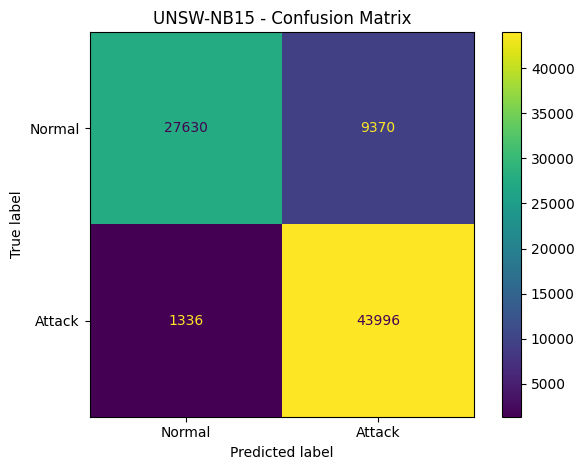

✅ Confusion matrix saved
/content/UNSW_NB15_Results/confusion_matrix.png


In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Normal", "Attack"],
    values_format="d"
)

plt.title("UNSW-NB15 - Confusion Matrix")
plt.tight_layout()

cm_path = os.path.join(
    unsw_results_path,
    "confusion_matrix.png"
)

plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Confusion matrix saved")
print(cm_path)

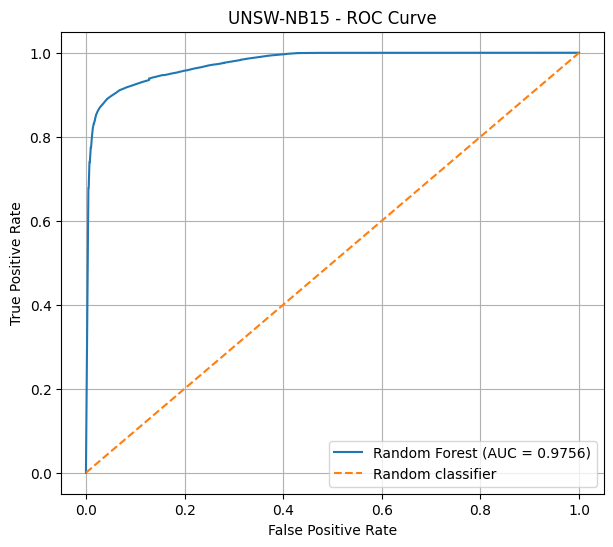

✅ ROC curve saved
/content/UNSW_NB15_Results/roc_curve.png


In [46]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.title("UNSW-NB15 - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)

roc_path = os.path.join(
    unsw_results_path,
    "roc_curve.png"
)

plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ ROC curve saved")
print(roc_path)

In [47]:
print("Files created:")

for file in os.listdir(unsw_results_path):
    path = os.path.join(unsw_results_path, file)
    print(file, "|", os.path.getsize(path), "bytes")

Files created:
metrics.json | 238 bytes
confusion_matrix.png | 99338 bytes
roc_curve.png | 134732 bytes


In [48]:
import shutil

zip_path = shutil.make_archive(
    "/content/UNSW_NB15_Results",
    "zip",
    "/content/UNSW_NB15_Results"
)

print("Created:", zip_path)

Created: /content/UNSW_NB15_Results.zip


In [ ]:
from google.colab import files

files.download("/content/UNSW_NB15_Results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
import pandas as pd
import numpy as np

# Create the anomaly detection report
unsw_report = pd.DataFrame({
    "Actual": np.where(y_test == 1, "Attack", "Normal"),
    "Predicted": np.where(y_pred == 1, "Attack", "Normal"),
    "Attack_Probability": y_pred_proba
})

# Add prediction status
unsw_report["Detection_Status"] = np.where(
    y_test == y_pred,
    "Correct",
    "Incorrect"
)

print("=" * 60)
print("UNSW-NB15 ANOMALY DETECTION REPORT")
print("=" * 60)

print("\nTotal records:", len(unsw_report))
print("Normal records:", (unsw_report["Predicted"] == "Normal").sum())
print("Attack records:", (unsw_report["Predicted"] == "Attack").sum())

print("\nDetection results:")
print(unsw_report["Detection_Status"].value_counts())

print("\nFirst 10 records:")
display(unsw_report.head(10))

UNSW-NB15 ANOMALY DETECTION REPORT

Total records: 82332
Normal records: 28966
Attack records: 53366

Detection results:
Detection_Status
Correct      71626
Incorrect    10706
Name: count, dtype: int64

First 10 records:


,Actual,Predicted,Attack_Probability,Detection_Status
0,Normal,Attack,0.950000,Incorrect
1,Normal,Attack,0.900000,Incorrect
2,Normal,Attack,0.521083,Incorrect
3,Normal,Attack,0.751463,Incorrect
4,Normal,Attack,0.712384,Incorrect
5,Normal,Attack,0.945398,Incorrect
6,Normal,Normal,0.380000,Correct
7,Normal,Attack,0.710000,Incorrect
8,Normal,Normal,0.000000,Correct
9,Normal,Normal,0.000000,Correct


In [50]:
# Add anomaly severity based on attack probability

def get_severity(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.70:
        return "Medium"
    else:
        return "High"

unsw_report["Severity"] = unsw_report["Attack_Probability"].apply(get_severity)

print("=" * 60)
print("UNSW-NB15 ANOMALY SEVERITY SUMMARY")
print("=" * 60)

print("\nSeverity distribution:")
print(unsw_report["Severity"].value_counts())

print("\nSeverity distribution for predicted attacks:")
print(
    unsw_report.loc[
        unsw_report["Predicted"] == "Attack",
        "Severity"
    ].value_counts()
)

print("\nUpdated report:")
display(unsw_report.head(10))

UNSW-NB15 ANOMALY SEVERITY SUMMARY

Severity distribution:
Severity
High      46127
Low       23292
Medium    12913
Name: count, dtype: int64

Severity distribution for predicted attacks:
Severity
High      46127
Medium     7239
Name: count, dtype: int64

Updated report:


,Actual,Predicted,Attack_Probability,Detection_Status,Severity
0,Normal,Attack,0.950000,Incorrect,High
1,Normal,Attack,0.900000,Incorrect,High
2,Normal,Attack,0.521083,Incorrect,Medium
3,Normal,Attack,0.751463,Incorrect,High
4,Normal,Attack,0.712384,Incorrect,High
5,Normal,Attack,0.945398,Incorrect,High
6,Normal,Normal,0.380000,Correct,Medium
7,Normal,Attack,0.710000,Incorrect,High
8,Normal,Normal,0.000000,Correct,Low
9,Normal,Normal,0.000000,Correct,Low


In [51]:
import os

report_file = "/content/UNSW_NB15_Anomaly_Detection_Report.csv"

unsw_report.to_csv(report_file, index=False)

print("✅ UNSW-NB15 anomaly detection report saved")
print("Location:", report_file)
print("Rows:", len(unsw_report))
print("Columns:", len(unsw_report.columns))

✅ UNSW-NB15 anomaly detection report saved
Location: /content/UNSW_NB15_Anomaly_Detection_Report.csv
Rows: 82332
Columns: 5


In [52]:
print("Report columns:")
print(list(unsw_report.columns))

print("\nReport shape:")
print(unsw_report.shape)

print("\nSeverity counts:")
print(unsw_report["Severity"].value_counts())

Report columns:
['Actual', 'Predicted', 'Attack_Probability', 'Detection_Status', 'Severity']

Report shape:
(82332, 5)

Severity counts:
Severity
High      46127
Low       23292
Medium    12913
Name: count, dtype: int64


In [53]:
import os

report_file = "/content/UNSW_NB15_Anomaly_Detection_Report.csv"

print("File exists:", os.path.exists(report_file))
print("File size:", os.path.getsize(report_file), "bytes")

File exists: True
File size: 2669826 bytes


In [54]:
import shutil

zip_path = shutil.make_archive(
    "/content/UNSW_NB15_Anomaly_Detection_Report",
    "zip",
    root_dir="/content",
    base_dir="UNSW_NB15_Anomaly_Detection_Report.csv"
)

print("Created:", zip_path)

Created: /content/UNSW_NB15_Anomaly_Detection_Report.zip


In [ ]:
from google.colab import files

files.download("/content/UNSW_NB15_Anomaly_Detection_Report.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
# ============================================================
# UNSW-NB15 THREAT CLASSIFICATION
# STEP 1 — PREPARE THREAT CLASSIFICATION DATA
# ============================================================

import numpy as np
import pandas as pd

print("=" * 60)
print("UNSW-NB15 THREAT CLASSIFICATION")
print("STEP 1 — DATA PREPARATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Get the attack-category target
# ------------------------------------------------------------

# attack_cat was preserved in train/test and was only removed
# from X_train/X_test for the binary anomaly-detection model.

y_train_threat = train["attack_cat"].astype(str).str.strip()
y_test_threat = test["attack_cat"].astype(str).str.strip()

# ------------------------------------------------------------
# 2. Check for missing / empty threat labels
# ------------------------------------------------------------

missing_train = (
    y_train_threat.isna() |
    (y_train_threat.str.strip() == "")
).sum()

missing_test = (
    y_test_threat.isna() |
    (y_test_threat.str.strip() == "")
).sum()

print("\nTraining samples:", len(y_train_threat))
print("Testing samples :", len(y_test_threat))

print("\nMissing training threat labels:", missing_train)
print("Missing testing threat labels :", missing_test)

# ------------------------------------------------------------
# 3. Display dynamically detected threat classes
# ------------------------------------------------------------

train_classes = sorted(
    y_train_threat.dropna().unique().tolist()
)

test_classes = sorted(
    y_test_threat.dropna().unique().tolist()
)

all_classes = sorted(
    set(train_classes) | set(test_classes)
)

print("\nNumber of threat classes:", len(all_classes))

print("\nThreat classes:")

for threat_class in all_classes:
    print(" -", threat_class)

# ------------------------------------------------------------
# 4. Threat-class distribution
# ------------------------------------------------------------

print("\n============================================================")
print("TRAINING THREAT DISTRIBUTION")
print("============================================================")

print(
    y_train_threat.value_counts()
)

print("\n============================================================")
print("TESTING THREAT DISTRIBUTION")
print("============================================================")

print(
    y_test_threat.value_counts()
)

# ------------------------------------------------------------
# 5. Verify feature data
# ------------------------------------------------------------

print("\n============================================================")
print("FEATURE DATA")
print("============================================================")

print(
    "Training feature shape:",
    X_train_processed.shape
)

print(
    "Testing feature shape :",
    X_test_processed.shape
)

print(
    "Training labels       :",
    y_train_threat.shape
)

print(
    "Testing labels        :",
    y_test_threat.shape
)

# ------------------------------------------------------------
# 6. Final validation
# ------------------------------------------------------------

# Sparse matrices must use shape[0] instead of len()

train_feature_rows = X_train_processed.shape[0]
test_feature_rows = X_test_processed.shape[0]

data_ready = (
    train_feature_rows == len(y_train_threat)
    and
    test_feature_rows == len(y_test_threat)
    and
    len(all_classes) > 1
)

print("\n============================================================")
print("FINAL DATA VALIDATION")
print("============================================================")

print(
    "Training feature rows :",
    train_feature_rows
)

print(
    "Training threat labels:",
    len(y_train_threat)
)

print(
    "Testing feature rows  :",
    test_feature_rows
)

print(
    "Testing threat labels :",
    len(y_test_threat)
)

print(
    "Number of classes     :",
    len(all_classes)
)

print(
    "Feature/label counts match:",
    (
        train_feature_rows == len(y_train_threat)
        and
        test_feature_rows == len(y_test_threat)
    )
)

print("\n============================================================")

if data_ready:

    print("✅ UNSW-NB15 THREAT CLASSIFICATION DATA READY")

else:

    print("❌ THREAT CLASSIFICATION DATA NEEDS ATTENTION")

print("============================================================")

UNSW-NB15 THREAT CLASSIFICATION
STEP 1 — DATA PREPARATION

Training samples: 175341
Testing samples : 82332

Missing training threat labels: 0
Missing testing threat labels : 0

Number of threat classes: 10

Threat classes:
 - Analysis
 - Backdoor
 - DoS
 - Exploits
 - Fuzzers
 - Generic
 - Normal
 - Reconnaissance
 - Shellcode
 - Worms

TRAINING THREAT DISTRIBUTION
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

TESTING THREAT DISTRIBUTION
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

FEATURE DATA
Training feature shape: (175341, 1

In [57]:
# ============================================================
# UNSW-NB15 THREAT CLASSIFICATION
# STEP 2 — TRAIN THREAT CLASSIFICATION MODEL
# ============================================================

from sklearn.ensemble import RandomForestClassifier

print("=" * 60)
print("UNSW-NB15 THREAT CLASSIFICATION MODEL")
print("=" * 60)

# ------------------------------------------------------------
# 1. Create the threat classification model
# ------------------------------------------------------------

unsw_threat_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# ------------------------------------------------------------
# 2. Train using the existing processed features
# ------------------------------------------------------------

print("\nTraining threat classification model...")

unsw_threat_model.fit(
    X_train_processed,
    y_train_threat
)

print("\n✅ Threat classification model trained successfully!")

# ------------------------------------------------------------
# 3. Generate predictions
# ------------------------------------------------------------

unsw_threat_predictions = (
    unsw_threat_model.predict(
        X_test_processed
    )
)

# ------------------------------------------------------------
# 4. Generate prediction probabilities
# ------------------------------------------------------------

unsw_threat_probabilities = (
    unsw_threat_model.predict_proba(
        X_test_processed
    )
)

# ------------------------------------------------------------
# 5. Dynamically obtain model classes
# ------------------------------------------------------------

unsw_threat_classes = list(
    unsw_threat_model.classes_
)

# ------------------------------------------------------------
# 6. Verification
# ------------------------------------------------------------

print("\n============================================================")
print("THREAT CLASSIFICATION MODEL OUTPUT")
print("============================================================")

print(
    "Training samples:",
    X_train_processed.shape[0]
)

print(
    "Testing samples :",
    X_test_processed.shape[0]
)

print(
    "Number of features:",
    X_train_processed.shape[1]
)

print(
    "Number of classes:",
    len(unsw_threat_classes)
)

print(
    "Prediction records:",
    len(unsw_threat_predictions)
)

print(
    "Probability shape:",
    unsw_threat_probabilities.shape
)

print("\nThreat classes:")

for threat_class in unsw_threat_classes:
    print(" -", threat_class)

print("\n============================================================")
print("STEP 2 COMPLETE")
print("============================================================")

UNSW-NB15 THREAT CLASSIFICATION MODEL

Training threat classification model...

✅ Threat classification model trained successfully!

THREAT CLASSIFICATION MODEL OUTPUT
Training samples: 175341
Testing samples : 82332
Number of features: 186
Number of classes: 10
Prediction records: 82332
Probability shape: (82332, 10)

Threat classes:
 - Analysis
 - Backdoor
 - DoS
 - Exploits
 - Fuzzers
 - Generic
 - Normal
 - Reconnaissance
 - Shellcode
 - Worms

STEP 2 COMPLETE


In [58]:
# ============================================================
# UNSW-NB15 THREAT CLASSIFICATION
# STEP 3 — VERIFY PREDICTIONS AND PROBABILITIES
# ============================================================

import numpy as np

print("=" * 60)
print("UNSW-NB15 THREAT CLASSIFICATION VERIFICATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Basic prediction checks
# ------------------------------------------------------------

test_records = X_test_processed.shape[0]
prediction_records = len(unsw_threat_predictions)
probability_rows = unsw_threat_probabilities.shape[0]
probability_classes = unsw_threat_probabilities.shape[1]

print("\nTest records       :", test_records)
print("Predictions        :", prediction_records)
print("Probability rows   :", probability_rows)
print("Number of classes  :", probability_classes)

# ------------------------------------------------------------
# 2. Verify prediction lengths
# ------------------------------------------------------------

prediction_lengths_match = (
    test_records == prediction_records
    and
    test_records == probability_rows
)

print(
    "\nAll prediction lengths match:",
    prediction_lengths_match
)

# ------------------------------------------------------------
# 3. Verify probability dimensions
# ------------------------------------------------------------

probability_shape_valid = (
    probability_classes ==
    len(unsw_threat_classes)
)

print(
    "Probability class count matches:",
    probability_shape_valid
)

# ------------------------------------------------------------
# 4. Verify probability values
# ------------------------------------------------------------

probabilities_valid = (
    np.all(unsw_threat_probabilities >= 0)
    and
    np.all(unsw_threat_probabilities <= 1)
)

print(
    "All probability values valid:",
    probabilities_valid
)

# ------------------------------------------------------------
# 5. Verify probability rows sum to 1
# ------------------------------------------------------------

probability_sums = (
    unsw_threat_probabilities.sum(axis=1)
)

probability_rows_valid = np.allclose(
    probability_sums,
    1.0,
    atol=1e-6
)

print(
    "Probability rows sum to 1:",
    probability_rows_valid
)

# ------------------------------------------------------------
# 6. Verify predicted classes
# ------------------------------------------------------------

predicted_classes_valid = all(
    prediction in unsw_threat_classes
    for prediction in unsw_threat_predictions
)

print(
    "All predictions belong to model classes:",
    predicted_classes_valid
)

# ------------------------------------------------------------
# 7. Display predicted threat distribution
# ------------------------------------------------------------

print("\n============================================================")
print("PREDICTED THREAT DISTRIBUTION")
print("============================================================")

prediction_distribution = (
    pd.Series(
        unsw_threat_predictions,
        name="Predicted_Threat"
    )
    .value_counts()
)

print(prediction_distribution)

# ------------------------------------------------------------
# 8. Final verification
# ------------------------------------------------------------

all_checks_passed = (
    prediction_lengths_match
    and
    probability_shape_valid
    and
    probabilities_valid
    and
    probability_rows_valid
    and
    predicted_classes_valid
)

print("\n============================================================")

if all_checks_passed:

    print("✅ THREAT PREDICTION VERIFICATION PASSED")

else:

    print("❌ THREAT PREDICTION VERIFICATION NEEDS ATTENTION")

print("============================================================")

UNSW-NB15 THREAT CLASSIFICATION VERIFICATION

Test records       : 82332
Predictions        : 82332
Probability rows   : 82332
Number of classes  : 10

All prediction lengths match: True
Probability class count matches: True
All probability values valid: True
Probability rows sum to 1: True
All predictions belong to model classes: True

PREDICTED THREAT DISTRIBUTION
Predicted_Threat
Normal            30418
Generic           18268
Fuzzers           11129
Exploits           9669
Backdoor           4818
DoS                3812
Reconnaissance     2990
Analysis            791
Shellcode           423
Worms                14
Name: count, dtype: int64

✅ THREAT PREDICTION VERIFICATION PASSED


In [59]:
# ============================================================
# UNSW-NB15 THREAT CLASSIFICATION
# STEP 4 — EVALUATE THREAT CLASSIFICATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("=" * 60)
print("UNSW-NB15 THREAT CLASSIFICATION METRICS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Calculate metrics
# ------------------------------------------------------------

threat_accuracy = accuracy_score(
    y_test_threat,
    unsw_threat_predictions
)

threat_precision = precision_score(
    y_test_threat,
    unsw_threat_predictions,
    average="weighted",
    zero_division=0
)

threat_recall = recall_score(
    y_test_threat,
    unsw_threat_predictions,
    average="weighted",
    zero_division=0
)

threat_f1 = f1_score(
    y_test_threat,
    unsw_threat_predictions,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# 2. Print overall metrics
# ------------------------------------------------------------

print("\n============================================================")
print("OVERALL PERFORMANCE")
print("============================================================")

print(
    f"Accuracy  : {threat_accuracy * 100:.2f}%"
)

print(
    f"Precision : {threat_precision * 100:.2f}%"
)

print(
    f"Recall    : {threat_recall * 100:.2f}%"
)

print(
    f"F1-Score  : {threat_f1 * 100:.2f}%"
)

# ------------------------------------------------------------
# 3. Detailed classification report
# ------------------------------------------------------------

print("\n============================================================")
print("CLASSIFICATION REPORT")
print("============================================================")

threat_classification_report = classification_report(
    y_test_threat,
    unsw_threat_predictions,
    labels=unsw_threat_classes,
    zero_division=0
)

print(threat_classification_report)

# ------------------------------------------------------------
# 4. Store detailed report as dictionary
# ------------------------------------------------------------

threat_report_dict = classification_report(
    y_test_threat,
    unsw_threat_predictions,
    labels=unsw_threat_classes,
    output_dict=True,
    zero_division=0
)

print("\n============================================================")
print("THREAT CLASSIFICATION EVALUATION COMPLETE")
print("============================================================")

UNSW-NB15 THREAT CLASSIFICATION METRICS

OVERALL PERFORMANCE
Accuracy  : 74.93%
Precision : 83.16%
Recall    : 74.93%
F1-Score  : 78.25%

CLASSIFICATION REPORT
                precision    recall  f1-score   support

      Analysis       0.02      0.03      0.03       677
      Backdoor       0.03      0.28      0.06       583
           DoS       0.27      0.25      0.26      4089
      Exploits       0.75      0.65      0.70     11132
       Fuzzers       0.30      0.55      0.39      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.94      0.78      0.85     37000
Reconnaissance       0.93      0.79      0.86      3496
     Shellcode       0.44      0.49      0.47       378
         Worms       0.57      0.18      0.28        44

      accuracy                           0.75     82332
     macro avg       0.53      0.50      0.49     82332
  weighted avg       0.83      0.75      0.78     82332


THREAT CLASSIFICATION EVALUATION COMPLETE


In [60]:
# ============================================================
# UNSW-NB15 THREAT CLASSIFICATION
# STEP 5 — GENERATE THREAT CLASSIFICATION REPORT
# ============================================================

import numpy as np
import pandas as pd

print("=" * 60)
print("UNSW-NB15 THREAT CLASSIFICATION REPORT")
print("=" * 60)

# ------------------------------------------------------------
# 1. Get maximum prediction probability
# ------------------------------------------------------------

threat_max_probability = (
    np.max(
        unsw_threat_probabilities,
        axis=1
    )
)

# Convert probability to percentage
threat_probability_percent = (
    threat_max_probability * 100
)

# ------------------------------------------------------------
# 2. Create threat report
# ------------------------------------------------------------

unsw_threat_report = pd.DataFrame({
    "Actual_Threat": y_test_threat.to_numpy(),

    "Predicted_Threat": unsw_threat_predictions,

    "Threat_Probability": np.round(
        threat_probability_percent,
        2
    )
})

# ------------------------------------------------------------
# 3. Calculate threat level dynamically
# ------------------------------------------------------------

def calculate_threat_level(row):

    predicted_threat = row["Predicted_Threat"]
    probability = row["Threat_Probability"]

    # Normal traffic
    if predicted_threat == "Normal":
        return "Low"

    # Attack/threat traffic
    if probability >= 80:
        return "High"

    if probability >= 50:
        return "Medium"

    return "Low"


unsw_threat_report["Threat_Level"] = (
    unsw_threat_report.apply(
        calculate_threat_level,
        axis=1
    )
)

# ------------------------------------------------------------
# 4. Verify report
# ------------------------------------------------------------

print("\n============================================================")
print("REPORT INFORMATION")
print("============================================================")

print(
    "Report shape:",
    unsw_threat_report.shape
)

print(
    "\nReport columns:"
)

print(
    list(unsw_threat_report.columns)
)

# ------------------------------------------------------------
# 5. Display first records
# ------------------------------------------------------------

print("\n============================================================")
print("FIRST 10 RECORDS")
print("============================================================")

print(
    unsw_threat_report.head(10)
)

# ------------------------------------------------------------
# 6. Predicted threat distribution
# ------------------------------------------------------------

print("\n============================================================")
print("PREDICTED THREAT DISTRIBUTION")
print("============================================================")

print(
    unsw_threat_report[
        "Predicted_Threat"
    ].value_counts()
)

# ------------------------------------------------------------
# 7. Threat level distribution
# ------------------------------------------------------------

print("\n============================================================")
print("THREAT LEVEL DISTRIBUTION")
print("============================================================")

print(
    unsw_threat_report[
        "Threat_Level"
    ].value_counts()
)

# ------------------------------------------------------------
# 8. Report verification
# ------------------------------------------------------------

print("\n============================================================")
print("REPORT VERIFICATION")
print("============================================================")

print(
    "Actual records       :",
    len(unsw_threat_report["Actual_Threat"])
)

print(
    "Predicted records    :",
    len(unsw_threat_report["Predicted_Threat"])
)

print(
    "Probability records  :",
    len(unsw_threat_report["Threat_Probability"])
)

print(
    "Threat level records :",
    len(unsw_threat_report["Threat_Level"])
)

all_lengths_match = (
    len(unsw_threat_report["Actual_Threat"])
    ==
    len(unsw_threat_report["Predicted_Threat"])
    ==
    len(unsw_threat_report["Threat_Probability"])
    ==
    len(unsw_threat_report["Threat_Level"])
)

print(
    "\nAll report lengths match:",
    all_lengths_match
)

print("\n============================================================")
print("THREAT CLASSIFICATION REPORT COMPLETE")
print("============================================================")

UNSW-NB15 THREAT CLASSIFICATION REPORT

REPORT INFORMATION
Report shape: (82332, 4)

Report columns:
['Actual_Threat', 'Predicted_Threat', 'Threat_Probability', 'Threat_Level']

FIRST 10 RECORDS
  Actual_Threat Predicted_Threat  Threat_Probability Threat_Level
0        Normal        Shellcode               83.00         High
1        Normal          Fuzzers               79.50       Medium
2        Normal          Fuzzers               72.64       Medium
3        Normal          Fuzzers               69.67       Medium
4        Normal          Fuzzers               77.36       Medium
5        Normal          Fuzzers               90.86         High
6        Normal           Normal               62.50          Low
7        Normal           Normal               31.50          Low
8        Normal           Normal              100.00          Low
9        Normal           Normal              100.00          Low

PREDICTED THREAT DISTRIBUTION
Predicted_Threat
Normal            30418
Generic

In [61]:
# ============================================================
# UNSW-NB15 THREAT CLASSIFICATION
# STEP 6 — SAVE MODEL ARTIFACTS AND REPORT
# ============================================================

import os
import json
import joblib

print("=" * 60)
print("UNSW-NB15 THREAT CLASSIFICATION ARTIFACTS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Create output folders
# ------------------------------------------------------------

base_path = (
    "/content/drive/MyDrive/"
    "NetShield_AI_Milestone_2"
)

models_path = os.path.join(
    base_path,
    "models",
    "UNSW_NB15"
)

reports_path = os.path.join(
    base_path,
    "reports",
    "UNSW_NB15"
)

os.makedirs(
    models_path,
    exist_ok=True
)

os.makedirs(
    reports_path,
    exist_ok=True
)

print("\nModel path :", models_path)
print("Report path:", reports_path)

# ------------------------------------------------------------
# 2. Save threat classifier
# ------------------------------------------------------------

classifier_path = os.path.join(
    models_path,
    "UNSW_NB15_ThreatClassifier.pkl"
)

joblib.dump(
    unsw_threat_model,
    classifier_path
)

print(
    "\n✅ Threat classifier saved!"
)

print(classifier_path)

# ------------------------------------------------------------
# 3. Save feature names
# ------------------------------------------------------------

feature_names_path = os.path.join(
    models_path,
    "UNSW_NB15_Threat_FeatureNames.pkl"
)

# The processed data contains 186 features.
# If the preprocessing pipeline provides feature names,
# use them; otherwise create stable feature identifiers.

if hasattr(
    X_train_processed,
    "columns"
):

    threat_feature_names = list(
        X_train_processed.columns
    )

elif hasattr(
    unsw_threat_model,
    "feature_names_in_"
):

    threat_feature_names = list(
        unsw_threat_model.feature_names_in_
    )

else:

    threat_feature_names = [
        f"feature_{i}"
        for i in range(
            X_train_processed.shape[1]
        )
    ]

joblib.dump(
    threat_feature_names,
    feature_names_path
)

print(
    "\n✅ Feature names saved!"
)

print(
    "Number of features:",
    len(threat_feature_names)
)

print(feature_names_path)

# ------------------------------------------------------------
# 4. Save threat classes
# ------------------------------------------------------------

classes_path = os.path.join(
    models_path,
    "UNSW_NB15_Threat_Classes.pkl"
)

joblib.dump(
    list(unsw_threat_classes),
    classes_path
)

print(
    "\n✅ Threat classes saved!"
)

print(
    "Number of classes:",
    len(unsw_threat_classes)
)

print("\nThreat classes:")

for threat_class in unsw_threat_classes:
    print(" -", threat_class)

print(classes_path)

# ------------------------------------------------------------
# 5. Save metadata
# ------------------------------------------------------------

metadata_path = os.path.join(
    models_path,
    "UNSW_NB15_Threat_Metadata.json"
)

metadata = {
    "Dataset": "UNSW-NB15",
    "Model": "Random Forest",
    "Task": "Threat Classification",
    "Number_of_features": int(
        X_train_processed.shape[1]
    ),
    "Number_of_classes": len(
        unsw_threat_classes
    ),
    "Threat_classes": list(
        unsw_threat_classes
    ),
    "Training_samples": int(
        X_train_processed.shape[0]
    ),
    "Testing_samples": int(
        X_test_processed.shape[0]
    ),
    "Accuracy": float(
        threat_accuracy
    ),
    "Precision_weighted": float(
        threat_precision
    ),
    "Recall_weighted": float(
        threat_recall
    ),
    "F1_weighted": float(
        threat_f1
    )
}

with open(
    metadata_path,
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

print(
    "\n✅ Metadata saved!"
)

print(metadata_path)

# ------------------------------------------------------------
# 6. Save threat classification report
# ------------------------------------------------------------

report_path = os.path.join(
    reports_path,
    "UNSW_NB15_Threat_Classification_Report.csv"
)

unsw_threat_report.to_csv(
    report_path,
    index=False
)

print(
    "\n✅ Threat classification report saved!"
)

print(report_path)

# ------------------------------------------------------------
# 7. Verify all artifacts
# ------------------------------------------------------------

print("\n============================================================")
print("UNSW-NB15 THREAT CLASSIFICATION ARTIFACTS")
print("============================================================")

artifacts = {
    "UNSW_NB15_ThreatClassifier.pkl":
        classifier_path,

    "UNSW_NB15_Threat_FeatureNames.pkl":
        feature_names_path,

    "UNSW_NB15_Threat_Classes.pkl":
        classes_path,

    "UNSW_NB15_Threat_Metadata.json":
        metadata_path,

    "UNSW_NB15_Threat_Classification_Report.csv":
        report_path
}

all_artifacts_saved = True

for name, path in artifacts.items():

    exists = os.path.exists(path)

    print(
        "✅" if exists else "❌",
        name,
        ":",
        exists
    )

    if not exists:
        all_artifacts_saved = False

print("\n============================================================")

if all_artifacts_saved:

    print("✅ STEP 6 COMPLETE")
    print("All UNSW-NB15 threat artifacts saved successfully.")

else:

    print("⚠️ STEP 6 NEEDS ATTENTION")
    print("One or more artifacts were not saved.")

print("============================================================")

UNSW-NB15 THREAT CLASSIFICATION ARTIFACTS

Model path : /content/drive/MyDrive/NetShield_AI_Milestone_2/models/UNSW_NB15
Report path: /content/drive/MyDrive/NetShield_AI_Milestone_2/reports/UNSW_NB15

✅ Threat classifier saved!
/content/drive/MyDrive/NetShield_AI_Milestone_2/models/UNSW_NB15/UNSW_NB15_ThreatClassifier.pkl

✅ Feature names saved!
Number of features: 186
/content/drive/MyDrive/NetShield_AI_Milestone_2/models/UNSW_NB15/UNSW_NB15_Threat_FeatureNames.pkl

✅ Threat classes saved!
Number of classes: 10

Threat classes:
 - Analysis
 - Backdoor
 - DoS
 - Exploits
 - Fuzzers
 - Generic
 - Normal
 - Reconnaissance
 - Shellcode
 - Worms
/content/drive/MyDrive/NetShield_AI_Milestone_2/models/UNSW_NB15/UNSW_NB15_Threat_Classes.pkl

✅ Metadata saved!
/content/drive/MyDrive/NetShield_AI_Milestone_2/models/UNSW_NB15/UNSW_NB15_Threat_Metadata.json

✅ Threat classification report saved!
/content/drive/MyDrive/NetShield_AI_Milestone_2/reports/UNSW_NB15/UNSW_NB15_Threat_Classification_Repo

In [62]:
# ============================================================
# UNSW-NB15 — MANUAL GOOGLE DRIVE FILE ORGANIZATION
# ============================================================

import os
import shutil

# ------------------------------------------------------------
# Source folder where Step 6 saved the files
# ------------------------------------------------------------

source_models = (
    "/content/drive/MyDrive/"
    "NetShield_AI_Milestone_2/models/UNSW_NB15"
)

source_reports = (
    "/content/drive/MyDrive/"
    "NetShield_AI_Milestone_2/reports/UNSW_NB15"
)

# ------------------------------------------------------------
# Destination folders
# ------------------------------------------------------------

destination_models = (
    "/content/drive/MyDrive/"
    "NetShield_AI_Milestone_2/models/UNSW_NB15"
)

destination_reports = (
    "/content/drive/MyDrive/"
    "NetShield_AI_Milestone_2/reports/UNSW_NB15"
)

os.makedirs(destination_models, exist_ok=True)
os.makedirs(destination_reports, exist_ok=True)

# ------------------------------------------------------------
# Model artifacts
# ------------------------------------------------------------

model_files = [
    "UNSW_NB15_ThreatClassifier.pkl",
    "UNSW_NB15_Threat_FeatureNames.pkl",
    "UNSW_NB15_Threat_Classes.pkl",
    "UNSW_NB15_Threat_Metadata.json"
]

# ------------------------------------------------------------
# Report artifact
# ------------------------------------------------------------

report_files = [
    "UNSW_NB15_Threat_Classification_Report.csv"
]

# ------------------------------------------------------------
# Copy model files
# ------------------------------------------------------------

print("=" * 60)
print("UNSW-NB15 MODEL FILES")
print("=" * 60)

for filename in model_files:

    source = os.path.join(
        source_models,
        filename
    )

    destination = os.path.join(
        destination_models,
        filename
    )

    if os.path.exists(source):

        # Avoid unnecessary copying when source and destination
        # are already the same file.
        if os.path.abspath(source) != os.path.abspath(destination):
            shutil.copy2(source, destination)

        print("✅", filename)

    else:
        print("❌ NOT FOUND:", filename)

# ------------------------------------------------------------
# Copy report files
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("UNSW-NB15 REPORT FILES")
print("=" * 60)

for filename in report_files:

    source = os.path.join(
        source_reports,
        filename
    )

    destination = os.path.join(
        destination_reports,
        filename
    )

    if os.path.exists(source):

        if os.path.abspath(source) != os.path.abspath(destination):
            shutil.copy2(source, destination)

        print("✅", filename)

    else:
        print("❌ NOT FOUND:", filename)

# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL GOOGLE DRIVE VERIFICATION")
print("=" * 60)

all_files_ready = True

for filename in model_files:

    path = os.path.join(
        destination_models,
        filename
    )

    exists = os.path.isfile(path)

    print(
        "✅" if exists else "❌",
        filename,
        ":",
        exists
    )

    if not exists:
        all_files_ready = False

for filename in report_files:

    path = os.path.join(
        destination_reports,
        filename
    )

    exists = os.path.isfile(path)

    print(
        "✅" if exists else "❌",
        filename,
        ":",
        exists
    )

    if not exists:
        all_files_ready = False

print("\n" + "=" * 60)

if all_files_ready:
    print("✅ ALL UNSW-NB15 THREAT FILES ARE READY IN GOOGLE DRIVE")
else:
    print("❌ SOME FILES ARE MISSING")

print("=" * 60)

UNSW-NB15 MODEL FILES
✅ UNSW_NB15_ThreatClassifier.pkl
✅ UNSW_NB15_Threat_FeatureNames.pkl
✅ UNSW_NB15_Threat_Classes.pkl
✅ UNSW_NB15_Threat_Metadata.json

UNSW-NB15 REPORT FILES
✅ UNSW_NB15_Threat_Classification_Report.csv

FINAL GOOGLE DRIVE VERIFICATION
✅ UNSW_NB15_ThreatClassifier.pkl : True
✅ UNSW_NB15_Threat_FeatureNames.pkl : True
✅ UNSW_NB15_Threat_Classes.pkl : True
✅ UNSW_NB15_Threat_Metadata.json : True
✅ UNSW_NB15_Threat_Classification_Report.csv : True

✅ ALL UNSW-NB15 THREAT FILES ARE READY IN GOOGLE DRIVE


In [63]:
# ============================================================
# UNSW-NB15 THREAT CLASSIFICATION
# STEP 7 — CREATE ZIP FOR MANUAL GOOGLE DRIVE UPLOAD
# ============================================================

import os
import zipfile

base_path = "/content/drive/MyDrive/NetShield_AI_Milestone_2"

models_path = os.path.join(
    base_path,
    "models",
    "UNSW_NB15"
)

reports_path = os.path.join(
    base_path,
    "reports",
    "UNSW_NB15"
)

# ZIP will be created in Colab's /content folder
zip_path = "/content/UNSW_NB15_Threat_Classification_Artifacts.zip"

# Files to include
files_to_zip = [
    (
        os.path.join(
            models_path,
            "UNSW_NB15_ThreatClassifier.pkl"
        ),
        "models/UNSW_NB15/UNSW_NB15_ThreatClassifier.pkl"
    ),
    (
        os.path.join(
            models_path,
            "UNSW_NB15_Threat_FeatureNames.pkl"
        ),
        "models/UNSW_NB15/UNSW_NB15_Threat_FeatureNames.pkl"
    ),
    (
        os.path.join(
            models_path,
            "UNSW_NB15_Threat_Classes.pkl"
        ),
        "models/UNSW_NB15/UNSW_NB15_Threat_Classes.pkl"
    ),
    (
        os.path.join(
            models_path,
            "UNSW_NB15_Threat_Metadata.json"
        ),
        "models/UNSW_NB15/UNSW_NB15_Threat_Metadata.json"
    ),
    (
        os.path.join(
            reports_path,
            "UNSW_NB15_Threat_Classification_Report.csv"
        ),
        "reports/UNSW_NB15/UNSW_NB15_Threat_Classification_Report.csv"
    )
]

print("=" * 60)
print("CHECKING UNSW-NB15 THREAT ARTIFACTS")
print("=" * 60)

all_files_exist = True

for source, archive_name in files_to_zip:

    if os.path.isfile(source):
        print("✅", archive_name)
    else:
        print("❌ MISSING:", source)
        all_files_exist = False

if not all_files_exist:
    raise FileNotFoundError(
        "One or more UNSW threat-classification files are missing."
    )

# ------------------------------------------------------------
# Create ZIP
# ------------------------------------------------------------

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for source, archive_name in files_to_zip:

        zip_file.write(
            source,
            arcname=archive_name
        )

print("\n" + "=" * 60)
print("ZIP CREATED SUCCESSFULLY")
print("=" * 60)

print("\nZIP file:")
print(zip_path)

print("\nFiles inside ZIP:")

with zipfile.ZipFile(zip_path, "r") as zip_file:

    for name in zip_file.namelist():
        print("✅", name)

print("\n" + "=" * 60)
print("READY FOR MANUAL GOOGLE DRIVE UPLOAD")
print("=" * 60)

CHECKING UNSW-NB15 THREAT ARTIFACTS
✅ models/UNSW_NB15/UNSW_NB15_ThreatClassifier.pkl
✅ models/UNSW_NB15/UNSW_NB15_Threat_FeatureNames.pkl
✅ models/UNSW_NB15/UNSW_NB15_Threat_Classes.pkl
✅ models/UNSW_NB15/UNSW_NB15_Threat_Metadata.json
✅ reports/UNSW_NB15/UNSW_NB15_Threat_Classification_Report.csv

ZIP CREATED SUCCESSFULLY

ZIP file:
/content/UNSW_NB15_Threat_Classification_Artifacts.zip

Files inside ZIP:
✅ models/UNSW_NB15/UNSW_NB15_ThreatClassifier.pkl
✅ models/UNSW_NB15/UNSW_NB15_Threat_FeatureNames.pkl
✅ models/UNSW_NB15/UNSW_NB15_Threat_Classes.pkl
✅ models/UNSW_NB15/UNSW_NB15_Threat_Metadata.json
✅ reports/UNSW_NB15/UNSW_NB15_Threat_Classification_Report.csv

READY FOR MANUAL GOOGLE DRIVE UPLOAD


In [64]:
from google.colab import files

zip_file = "/content/UNSW_NB15_Threat_Classification_Artifacts.zip"

files.download(zip_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
# ============================================================
# UNSW-NB15 — RISK SCORING
# STEP 7
# ============================================================

import numpy as np
import pandas as pd

print("=" * 60)
print("UNSW-NB15 RISK SCORING SYSTEM")
print("=" * 60)

# ------------------------------------------------------------
# 1. Use the existing threat-classification report
# ------------------------------------------------------------

risk_report = unsw_threat_report.copy()

# ------------------------------------------------------------
# 2. Calculate dynamic risk score
#
# Score is based on:
#   - predicted threat
#   - prediction probability
#
# Normal traffic gets a low base risk.
# Threat traffic gets a score based on confidence.
# ------------------------------------------------------------

def calculate_risk_score(row):

    predicted_threat = row["Predicted_Threat"]
    probability = float(row["Threat_Probability"])

    # Normal traffic
    if predicted_threat == "Normal":
        score = probability * 0.10

    # Threat traffic
    else:
        score = probability

    return round(
        max(0, min(100, score)),
        2
    )


risk_report["Risk_Score"] = (
    risk_report.apply(
        calculate_risk_score,
        axis=1
    )
)

# ------------------------------------------------------------
# 3. Calculate risk level dynamically
# ------------------------------------------------------------

def calculate_risk_level(score):

    if score >= 80:
        return "Critical"

    elif score >= 60:
        return "High"

    elif score >= 30:
        return "Medium"

    else:
        return "Low"


risk_report["Risk_Level"] = (
    risk_report["Risk_Score"].apply(
        calculate_risk_level
    )
)

# ------------------------------------------------------------
# 4. Display report information
# ------------------------------------------------------------

print("\n============================================================")
print("RISK SCORING REPORT")
print("============================================================")

print("\nReport shape:")
print(risk_report.shape)

print("\nReport columns:")
print(list(risk_report.columns))

# ------------------------------------------------------------
# 5. Show first 10 records
# ------------------------------------------------------------

print("\n============================================================")
print("FIRST 10 RISK RECORDS")
print("============================================================")

print(
    risk_report.head(10).to_string(index=False)
)

# ------------------------------------------------------------
# 6. Risk score statistics
# ------------------------------------------------------------

print("\n============================================================")
print("RISK SCORE STATISTICS")
print("============================================================")

print(
    risk_report["Risk_Score"].describe()
)

# ------------------------------------------------------------
# 7. Risk level distribution
# ------------------------------------------------------------

print("\n============================================================")
print("RISK LEVEL DISTRIBUTION")
print("============================================================")

print(
    risk_report["Risk_Level"].value_counts()
)

# ------------------------------------------------------------
# 8. Threat-wise average risk score
# ------------------------------------------------------------

print("\n============================================================")
print("AVERAGE RISK SCORE BY THREAT")
print("============================================================")

threat_risk_summary = (
    risk_report
    .groupby("Predicted_Threat")["Risk_Score"]
    .agg(
        Count="count",
        Average_Risk_Score="mean",
        Maximum_Risk_Score="max"
    )
    .sort_values(
        "Average_Risk_Score",
        ascending=False
    )
)

threat_risk_summary[
    "Average_Risk_Score"
] = threat_risk_summary[
    "Average_Risk_Score"
].round(2)

print(threat_risk_summary)

# ------------------------------------------------------------
# 9. Verify risk scores
# ------------------------------------------------------------

print("\n============================================================")
print("RISK SCORE VERIFICATION")
print("============================================================")

score_values_valid = (
    risk_report["Risk_Score"].between(0, 100).all()
)

risk_levels_valid = (
    risk_report["Risk_Level"]
    .isin(["Low", "Medium", "High", "Critical"])
    .all()
)

no_missing_scores = (
    risk_report["Risk_Score"].notna().all()
)

no_missing_levels = (
    risk_report["Risk_Level"].notna().all()
)

print(
    "All risk scores between 0 and 100:",
    score_values_valid
)

print(
    "All risk levels valid:",
    risk_levels_valid
)

print(
    "No missing risk scores:",
    no_missing_scores
)

print(
    "No missing risk levels:",
    no_missing_levels
)

print(
    "Risk records:",
    len(risk_report)
)

all_risk_checks_passed = (
    score_values_valid
    and risk_levels_valid
    and no_missing_scores
    and no_missing_levels
)

print(
    "\nAll risk-scoring checks passed:",
    all_risk_checks_passed
)

print("\n============================================================")

if all_risk_checks_passed:
    print("✅ UNSW-NB15 RISK SCORING COMPLETE")
else:
    print("❌ RISK SCORING NEEDS ATTENTION")

print("============================================================")

UNSW-NB15 RISK SCORING SYSTEM

RISK SCORING REPORT

Report shape:
(82332, 6)

Report columns:
['Actual_Threat', 'Predicted_Threat', 'Threat_Probability', 'Threat_Level', 'Risk_Score', 'Risk_Level']

FIRST 10 RISK RECORDS
Actual_Threat Predicted_Threat  Threat_Probability Threat_Level  Risk_Score Risk_Level
       Normal        Shellcode               83.00         High       83.00   Critical
       Normal          Fuzzers               79.50       Medium       79.50       High
       Normal          Fuzzers               72.64       Medium       72.64       High
       Normal          Fuzzers               69.67       Medium       69.67       High
       Normal          Fuzzers               77.36       Medium       77.36       High
       Normal          Fuzzers               90.86         High       90.86   Critical
       Normal           Normal               62.50          Low        6.25        Low
       Normal           Normal               31.50          Low        3.15        

In [66]:
# ============================================================
# UNSW-NB15 — STEP 8
# SAVE RISK SCORING REPORT
# ============================================================

import os

base_path = (
    "/content/drive/MyDrive/"
    "NetShield_AI_Milestone_2"
)

risk_reports_path = os.path.join(
    base_path,
    "reports",
    "UNSW_NB15"
)

os.makedirs(
    risk_reports_path,
    exist_ok=True
)

risk_report_path = os.path.join(
    risk_reports_path,
    "UNSW_NB15_Risk_Scoring_Report.csv"
)

risk_report.to_csv(
    risk_report_path,
    index=False
)

print("=" * 60)
print("UNSW-NB15 RISK SCORING REPORT")
print("=" * 60)

print("\n✅ Risk scoring report saved!")
print(risk_report_path)

print("\nReport shape:")
print(risk_report.shape)

print("\nReport columns:")
print(list(risk_report.columns))

print("\nFile exists:")
print(os.path.exists(risk_report_path))

print("\n" + "=" * 60)
print("STEP 8 COMPLETE")
print("=" * 60)

UNSW-NB15 RISK SCORING REPORT

✅ Risk scoring report saved!
/content/drive/MyDrive/NetShield_AI_Milestone_2/reports/UNSW_NB15/UNSW_NB15_Risk_Scoring_Report.csv

Report shape:
(82332, 6)

Report columns:
['Actual_Threat', 'Predicted_Threat', 'Threat_Probability', 'Threat_Level', 'Risk_Score', 'Risk_Level']

File exists:
True

STEP 8 COMPLETE


In [67]:
# ============================================================
# UNSW-NB15 RISK SCORING
# CREATE ZIP FOR MANUAL GOOGLE DRIVE UPLOAD
# ============================================================

import os
import zipfile

risk_report_path = (
    "/content/drive/MyDrive/"
    "NetShield_AI_Milestone_2/"
    "reports/UNSW_NB15/"
    "UNSW_NB15_Risk_Scoring_Report.csv"
)

zip_path = (
    "/content/"
    "UNSW_NB15_Risk_Scoring_Report.zip"
)

# ------------------------------------------------------------
# Check file exists
# ------------------------------------------------------------

if not os.path.isfile(risk_report_path):
    raise FileNotFoundError(
        f"Risk report not found:\n{risk_report_path}"
    )

print("=" * 60)
print("CHECKING UNSW-NB15 RISK REPORT")
print("=" * 60)

print("✅ Risk report found")
print(risk_report_path)

# ------------------------------------------------------------
# Create ZIP
# ------------------------------------------------------------

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    zip_file.write(
        risk_report_path,
        arcname="reports/UNSW_NB15/UNSW_NB15_Risk_Scoring_Report.csv"
    )

print("\n" + "=" * 60)
print("ZIP CREATED SUCCESSFULLY")
print("=" * 60)

print("\nZIP file:")
print(zip_path)

# ------------------------------------------------------------
# Verify ZIP
# ------------------------------------------------------------

with zipfile.ZipFile(zip_path, "r") as zip_file:

    print("\nFiles inside ZIP:")

    for name in zip_file.namelist():
        print("✅", name)

print("\n" + "=" * 60)
print("READY FOR DOWNLOAD")
print("=" * 60)

CHECKING UNSW-NB15 RISK REPORT
✅ Risk report found
/content/drive/MyDrive/NetShield_AI_Milestone_2/reports/UNSW_NB15/UNSW_NB15_Risk_Scoring_Report.csv

ZIP CREATED SUCCESSFULLY

ZIP file:
/content/UNSW_NB15_Risk_Scoring_Report.zip

Files inside ZIP:
✅ reports/UNSW_NB15/UNSW_NB15_Risk_Scoring_Report.csv

READY FOR DOWNLOAD


In [68]:
# ============================================================
# DOWNLOAD UNSW RISK SCORING ZIP
# ============================================================

from google.colab import files

zip_path = (
    "/content/"
    "UNSW_NB15_Risk_Scoring_Report.zip"
)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>